# GKP State Preparation via GRAPE

Optimal control synthesis of a pulse that prepares a finite-energy GKP $\ket{0_L}$ state from vacuum in a single Kerr-nonlinear cavity driven by two-photon (squeezing) controls. The optimization uses gradient ascent in the Fourier domain with soft Lagrange-multiplier penalties enforcing amplitude limits, smoothness, and zero-amplitude boundaries.

## Imports

In [129]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

from gkp_optimal_control.grape import (
    System,
    TimeGrid,
    FourierBand,
    Penalties,
    run_grape,
    save_pulse,
    forward_evolve,
)
from gkp_optimal_control.hamiltonians import (
    kerr_cavity_drift,
    kerr_cavity_squeezing_controls,
)
from gkp_optimal_control.plotting import (
    plot_photon_number,
    plot_wigner,
    set_plot_style,
)
from gkp_optimal_control.states import fock_state, gkp_states, cat_states
from gkp_optimal_control.utils import wigner_trajectory
from gkp_optimal_control.animation import animate_wigner

set_plot_style()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Target state

The target is the finite-energy logical $\ket{0_L}$ for a square-lattice GKP code with primitive displacements $\alpha = \sqrt{\pi/2}$ and $\beta = i\sqrt{\pi/2}$. The envelope width $\Delta$ sets the effective squeezing; the Fock-space truncation must accommodate the full support of the state.

In [130]:
n_fock = 100
gkp_delta = 0.3
gkp_cutoff = 10
gkp_alpha = jnp.sqrt(np.pi / 2)
gkp_beta = jnp.sqrt(np.pi / 2) * 1j

vac = fock_state(n_fock, 0)
gkp_0, gkp_1 = gkp_states(n_fock, gkp_alpha, gkp_beta, gkp_delta, gkp_cutoff)
even_cat, _ = cat_states(n_fock, gkp_alpha)

psi_init = vac.astype(jnp.complex128)
psi_targ = gkp_0.astype(jnp.complex128)

tail_population = float(jnp.sum(jnp.abs(psi_targ[-10:]) ** 2))
print(f"Target tail population (top 10 Fock levels): {tail_population:.2e}")

Target tail population (top 10 Fock levels): 5.97e-07


## System Hamiltonian

Single Kerr-nonlinear cavity in the rotating frame:
$$H/\hbar = \frac{K}{2} \hat{a}^\dagger \hat{a}^\dagger \hat{a} \hat{a} + \epsilon_I(t)\,(a^2 + a^{\dagger 2}) + i\,\epsilon_Q(t)\,(a^2 - a^{\dagger 2}).$$

The two control fields are the in-phase and quadrature components of a two-photon (squeezing) drive. Frequencies are stored as angular rates ($2\pi \times \text{MHz} = \text{rad}/\mu s$) and times in microseconds.

In [131]:
K = 2 * jnp.pi * (0.1)  # Kerr nonlinearity, rad/μs

h_drift = kerr_cavity_drift(n_fock, kerr=K)
h_controls = kerr_cavity_squeezing_controls(n_fock)  # (2, dim, dim)

system = System(
    H_drift=h_drift,
    H_controls=h_controls,
    psi_init=psi_init,
    psi_targ=psi_targ,
)

## Optimization configuration

The pulse is parametrized in the Fourier domain with a hard frequency cutoff at $f_{\max}$. Soft penalties enforce amplitude limit $\epsilon_{\max}$, smoothness (squared-derivative), and zero amplitude in the first/last `boundary_n_zero` samples.

In [132]:
time_grid = TimeGrid(T=2.0, n_steps=500)  # 1.0 μs total, dt = 2 ns

band = FourierBand(f_max=100.0)  # MHz

penalties = Penalties(
    amp=0.1,
    deriv=1e-3,
    boundary=1.0,
    eps_max=10.0,
    boundary_n_zero=3,
)

## Run GRAPE

L-BFGS-B with analytic gradients via JAX autodiff. The first call pays a one-time JIT compilation cost; subsequent calls reuse the compiled cost-and-gradient function.

In [133]:
result, diag, params_to_pulse = run_grape(
    system,
    time_grid,
    band,
    penalties,
    seed=18,
    init_scale=0.01,
    maxiter=500,
)

 iter          loss         F      |grad|   elapsed
-------------------------------------------------------
   10     -0.388517   0.41507   5.962e+00     21.8s
   20     -0.459715   0.46824   2.706e+00     38.8s
   30     -0.600663   0.62110   1.267e+00     60.0s
   40     -0.697167   0.69911   6.165e-01     79.7s
   50     -0.716900   0.72007   9.392e-01     96.1s
   60     -0.739562   0.74150   4.996e-01    112.9s
   70     -0.753375   0.77139   3.176e+00    137.2s
   80     -0.802616   0.80661   1.731e+00    153.7s
   90     -0.828677   0.83061   5.438e-01    173.7s
  100     -0.834606   0.83636   4.717e-01    190.4s
  110     -0.858301   0.86063   1.213e+00    207.0s
  120     -0.902607   0.90630   7.842e-01    223.7s
  130     -0.915950   0.91902   5.272e-01    240.4s
  140     -0.927513   0.93012   4.317e-01    258.8s
  150     -0.934468   0.93706   4.122e-01    276.9s
  160     -0.938855   0.94113   2.878e-01    295.2s
  170     -0.944426   0.94672   3.495e-01    312.1s
  180   

In [123]:
# Multi-seed sweep
fidelities = []
for s in range(5):
    print(f"seed={s}")
    result, diag, _ = run_grape(
        system,
        time_grid,
        band,
        penalties,
        seed=s,
        init_scale=0.001,
        maxiter=200,
        verbose=True,
    )
    fidelities.append(diag["F"])
    print(f"  F = {diag['F']:.4f}")

print(f"\nFidelity range: {min(fidelities):.4f} - {max(fidelities):.4f}")

# Truncation check on the best run
best_seed = int(np.argmax(fidelities))
result, diag, _ = run_grape(
    system,
    time_grid,
    band,
    penalties,
    seed=best_seed,
    init_scale=0.001,
    maxiter=500,
    verbose=False,
)
pulse_jax = jnp.asarray(diag["pulse"])
_, traj = forward_evolve(
    pulse_jax,
    dt=time_grid.dt,
    psi_0=system.psi_init,
    h_drift=system.H_drift,
    h_controls=system.H_controls,
    return_history=True,
)
tail_pops = jnp.sum(jnp.abs(traj[:, -10:]) ** 2, axis=-1)
print(f"\nMax trajectory tail population: {float(jnp.max(tail_pops)):.2e}")

seed=0
 iter          loss         F      |grad|   elapsed
-------------------------------------------------------
   10     -0.570532   0.57089   2.726e-01     16.0s
   20     -0.570917   0.57111   2.270e-01     30.6s
   30     -0.571141   0.57125   9.211e-02     48.5s
   40     -0.571364   0.57153   3.691e-02     62.3s
   50     -0.571638   0.57189   8.239e-02     75.8s
   60     -0.571775   0.57200   4.888e-02     91.1s
   70     -0.571919   0.57214   1.366e-01    104.1s
   80     -0.572056   0.57229   6.429e-02    116.9s
   90     -0.572143   0.57239   8.072e-02    130.8s
  100     -0.572223   0.57246   8.897e-02    145.6s
  110     -0.572281   0.57249   3.516e-02    158.2s
  120     -0.572319   0.57254   3.825e-02    170.6s
  130     -0.572342   0.57252   5.821e-02    182.9s
  140     -0.572352   0.57253   1.825e-02    196.4s
  150     -0.572371   0.57254   3.957e-02    208.7s
  160     -0.572388   0.57256   1.966e-02    222.3s
  170     -0.572410   0.57259   2.443e-02    235.6s
 

KeyboardInterrupt: 

## Optimized pulse waveforms

Time-domain in-phase (I) and quadrature (Q) components of the two-photon drive, with the amplitude bound shown as a horizontal reference.

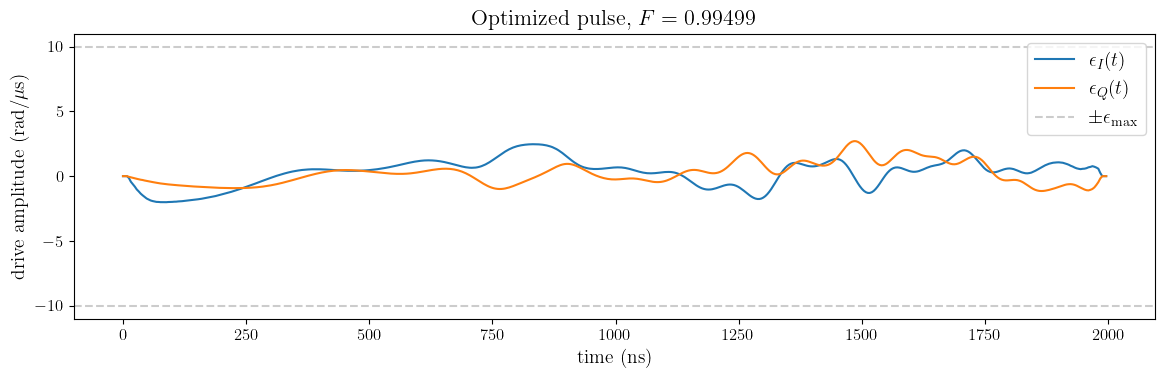

In [137]:
pulse = diag["pulse"]
times_ns = np.arange(time_grid.n_steps) * time_grid.dt * 1000

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(times_ns, pulse[0], label=r"$\epsilon_I(t)$")
ax.plot(times_ns, pulse[1], label=r"$\epsilon_Q(t)$")
ax.axhline(
    +penalties.eps_max, color="gray", linestyle="--", alpha=0.4, label=r"$\pm\epsilon_{\max}$"
)
ax.axhline(-penalties.eps_max, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("time (ns)")
ax.set_ylabel(r"drive amplitude (rad/$\mu$s)")
ax.set_title(rf"Optimized pulse, $F = {diag['F']:.5f}$")
ax.legend()
fig.tight_layout()
fig.savefig("../../figs/optimal_control/optimized_pulse_2us.pdf", bbox_inches="tight")
plt.show()

## Pulse spectrum

Frequency content of the optimized pulse. The hard cutoff at $f_{\max}$ is enforced by construction in the Fourier parametrization, not by a penalty.

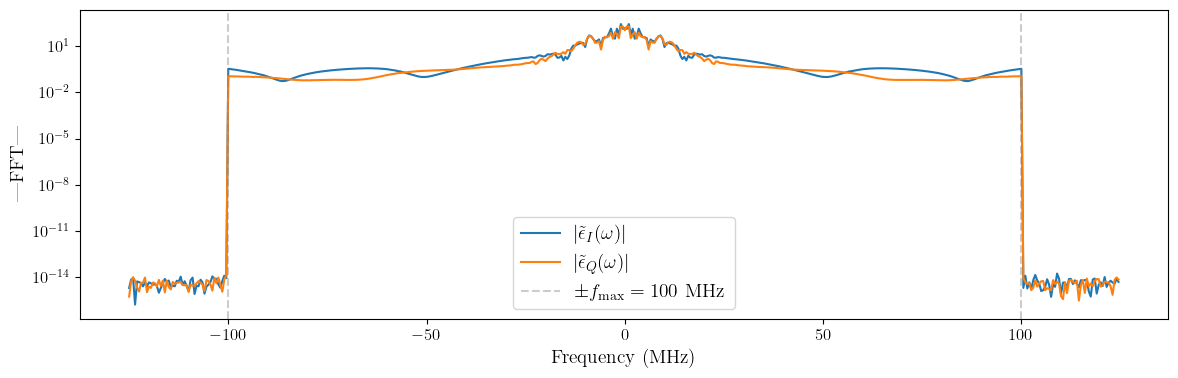

In [138]:
freqs = np.fft.fftshift(np.fft.fftfreq(time_grid.n_steps, d=time_grid.dt))
spectra = np.abs(np.fft.fftshift(np.fft.fft(pulse, axis=-1), axes=-1))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freqs, spectra[0], label=r"$|\tilde\epsilon_I(\omega)|$")
ax.plot(freqs, spectra[1], label=r"$|\tilde\epsilon_Q(\omega)|$")
ax.axvline(
    +band.f_max,
    color="gray",
    linestyle="--",
    alpha=0.4,
    label=rf"$\pm f_{{\max}} = {band.f_max:g}$ MHz",
)
ax.axvline(-band.f_max, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("|FFT|")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
fig.savefig("../../figs/optimal_control/optimized_pulse_FFT_2us.pdf", bbox_inches="tight")
plt.show()

## Final state vs. target

Wigner functions of the achieved final state and the target $\ket{0_L}$. A successful encoding reproduces the target's characteristic GKP lattice of positive and negative peaks.

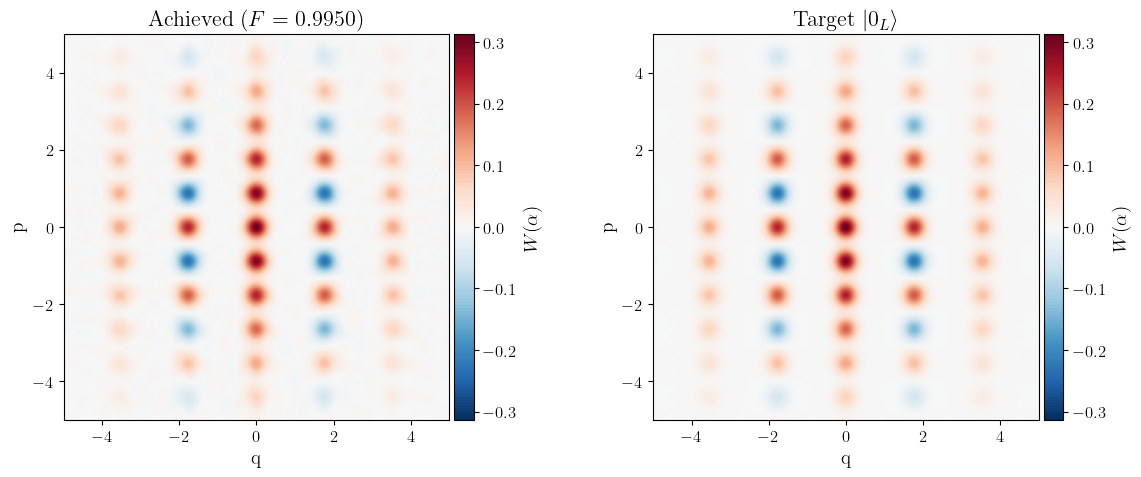

In [139]:
psi_final = jnp.asarray(diag["psi_final"])
psi_final = psi_final / jnp.linalg.norm(psi_final)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_wigner(psi_final, x_bound=5, y_bound=5, ax=axes[0], title=rf"Achieved ($F = {diag['F']:.4f}$)")
plot_wigner(psi_targ, x_bound=5, y_bound=5, ax=axes[1], title=r"Target $\ket{0_L}$")
fig.tight_layout()
fig.savefig(
    "../../figs/optimal_control/optimized_pulse__wigner_compared_2us.pdf", bbox_inches="tight"
)
plt.show()

In [140]:
# Get the trajectory and inspect max Fock occupation over time.
pulse_jax = jnp.asarray(diag["pulse"])
psi_f, traj = forward_evolve(
    pulse_jax,
    dt=time_grid.dt,
    psi_0=system.psi_init,
    h_drift=system.H_drift,
    h_controls=system.H_controls,
    return_history=True,
)
# Max tail population over the whole trajectory.
tail_pops = jnp.sum(jnp.abs(traj[:, -10:]) ** 2, axis=-1)
print(f"max trajectory tail population: {float(jnp.max(tail_pops)):.2e}")

max trajectory tail population: 1.33e-09


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1600x1200', '-pix_fmt', 'rgba', '-framerate', '25', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'libx264', '-pix_fmt', 'yuv420p', '-preset', 'fast', '-crf', '18', '-y', '../../vids/grape/vac_to_gkp_0_2.mp4']' returned non-zero exit status 255.

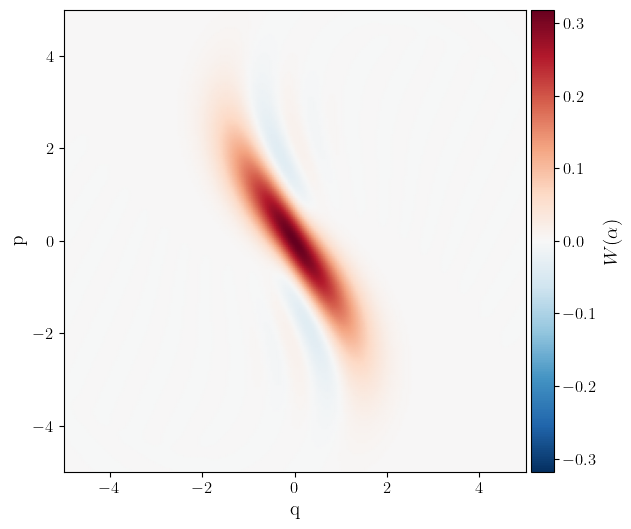

In [116]:
# Re-run the forward evolution, this time recording every intermediate state.
pulse_jax = jnp.asarray(diag["pulse"])
psi_f, traj = forward_evolve(
    pulse_jax,
    dt=time_grid.dt,
    psi_0=system.psi_init,
    h_drift=system.H_drift,
    h_controls=system.H_controls,
    return_history=True,
)
# traj has shape (n_steps, dim) -- one ket per slice.

# Wigner functions along the trajectory.
xvec, yvec, frames = wigner_trajectory(
    traj,
    x_bound=5.0,
    y_bound=5.0,
    grid_points=200,
)

# Render an animation.
animate_wigner(
    frames,
    xvec,
    yvec,
    # title=r'GRAPE trajectory $|0\rangle \to |0_L\rangle$',
    save_path="../../vids/grape/vac_to_gkp_0_2.mp4",
    dpi=200,
)

## Photon-number distributions

Diagonal of the density matrix in the Fock basis. The achieved distribution should track the target. Significant population near $n = n_{\text{fock}}$ would indicate the truncation is too tight.

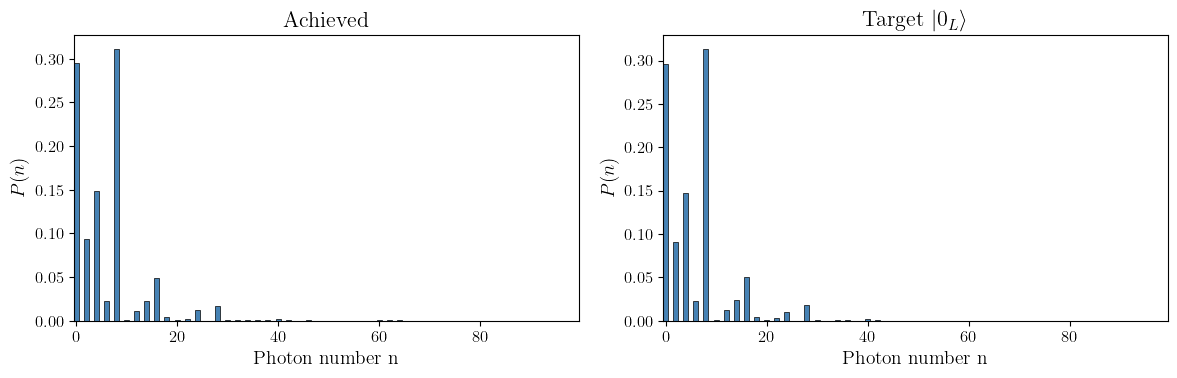

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_photon_number(psi_final, ax=axes[0], title="Achieved")
plot_photon_number(gkp_0, ax=axes[1], title=r"Target $\ket{0_L}$")
fig.tight_layout()
plt.show()

## Save the pulse

Persist the optimized pulse along with the parameters needed to reconstruct it on hardware (or in a follow-up notebook).

In [143]:
save_pulse(
    "../../data/gkp_state_prep.npz",
    pulse,
    metadata={
        "fidelity": diag["F"],
        "T_us": time_grid.T,
        "n_steps": time_grid.n_steps,
        "f_max_MHz": band.f_max,
        "eps_max": penalties.eps_max,
        "n_fock": n_fock,
        "gkp_delta": gkp_delta,
        "K_rad_per_us": float(K),
    },
)

In [148]:
K_per_2pi = -np.logspace(np.log10(0.005), np.log10(0.20), 8)  # MHz
K_per_2pi

array([-0.005     , -0.00846907, -0.01434503, -0.02429781, -0.04115597,
       -0.06971056, -0.11807672, -0.2       ])

In [150]:
K = 2 * jnp.pi * (0.1)  # Kerr nonlinearity, rad/μs

data = []

for K in K_values:
    h_drift = kerr_cavity_drift(n_fock, kerr=K)
    h_controls = kerr_cavity_squeezing_controls(n_fock)  # (2, dim, dim)

    system = System(
        H_drift=h_drift,
        H_controls=h_controls,
        psi_init=psi_init,
        psi_targ=psi_targ,
    )

    result, diag, params_to_pulse = run_grape(
        system,
        time_grid,
        band,
        penalties,
        seed=18,
        init_scale=0.01,
        maxiter=200,
    )

    data.append(diag)

 iter          loss         F      |grad|   elapsed
-------------------------------------------------------
   10     -0.513629   0.53105   2.593e+00     17.2s
   20     -0.546913   0.55395   6.915e-01     32.0s
   30     -0.558538   0.56100   4.181e-01     46.4s
   40     -0.563289   0.56509   4.780e-01     60.3s
   50     -0.564919   0.56662   1.646e-01     75.0s
   60     -0.567214   0.56896   1.382e-01     88.4s
   70     -0.567808   0.56896   1.667e-01    101.7s
   80     -0.568716   0.57001   1.519e-01    116.4s
   90     -0.569229   0.57061   1.577e-01    132.3s
  100     -0.569437   0.57071   1.875e-01    145.7s
  110     -0.569688   0.57097   3.187e-02    159.2s
  120     -0.569851   0.57096   6.953e-02    174.2s
  130     -0.569920   0.57093   1.935e-02    187.7s
  140     -0.569973   0.57089   2.896e-02    201.4s
  150     -0.570021   0.57092   3.877e-02    214.8s
  160     -0.570079   0.57098   7.314e-02    229.6s
  170     -0.570131   0.57101   4.134e-02    243.1s
  180   

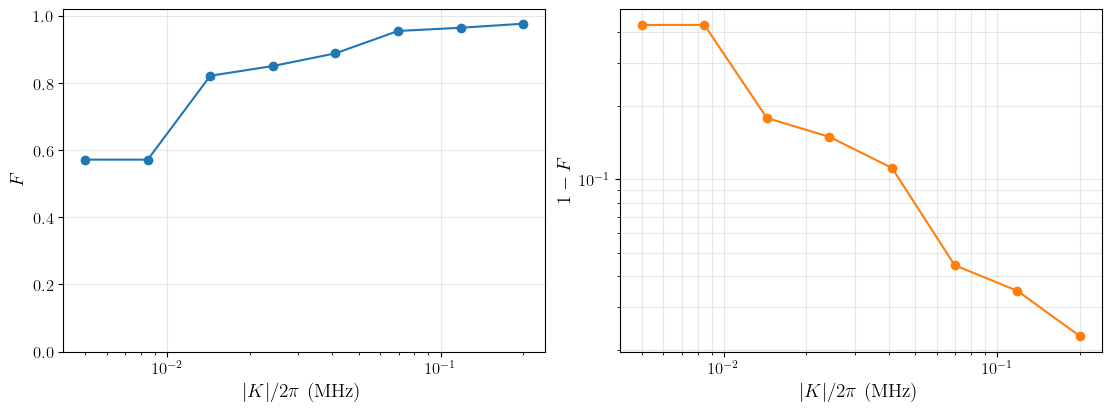


Results:
  K/2π (MHz)       |K|/2π          F          1-F
     -0.0050       0.0050     0.5721     4.28e-01
     -0.0085       0.0085     0.5720     4.28e-01
     -0.0143       0.0143     0.8221     1.78e-01
     -0.0243       0.0243     0.8510     1.49e-01
     -0.0412       0.0412     0.8889     1.11e-01
     -0.0697       0.0697     0.9555     4.45e-02
     -0.1181       0.1181     0.9651     3.49e-02
     -0.2000       0.2000     0.9772     2.28e-02


In [155]:
# Plot fidelity vs K from the sweep data
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams["text.usetex"] = True

# Extract fidelities — diag['F'] is a JAX scalar so float() to coerce
F_values = np.array([float(diag["F"]) for diag in data])

# Convert K back to MHz for plotting (K is in rad/μs)
K_MHz = np.asarray(K_values) / (2 * np.pi)
K_abs = np.abs(K_MHz)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

# Left: F vs |K| on log-x
ax = axes[0]
ax.semilogx(K_abs, F_values, "o-", markersize=6)
ax.set_xlabel(r"$|K|/2\pi$ (MHz)")
ax.set_ylabel(r"$F$")
ax.set_ylim(0, 1.02)
# ax.set_title('Fidelity vs Kerr rate')
ax.grid(alpha=0.3)

# Right: log infidelity on log-log
ax = axes[1]
infid = np.clip(1 - F_values, 1e-8, None)
ax.loglog(K_abs, infid, "o-", color="C1", markersize=6)
ax.set_xlabel(r"$|K|/2\pi$ (MHz)")
ax.set_ylabel(r"$1 - F$")
# ax.set_title('Log infidelity')
ax.grid(which="both", alpha=0.3)

# fig.suptitle(
#     f'GKP preparation vs cavity Kerr rate '
#     f'($n_{{Fock}}={n_fock}$, $\\Delta={gkp_delta}$, '
#     f'$T={float(time_grid.T):.2f}\\,\\mu$s, $f_{{\\max}}={float(band.f_max):.0f}$ MHz)',
#     fontsize=10,
# )

# fig.savefig('../K_sweep.png', dpi=200, bbox_inches='tight')
fig.savefig("../../figs/optimal_control/kerr_sweep.pdf", bbox_inches="tight")
plt.show()

# Print the data table for the writeup
print("\nResults:")
print(f"{'K/2π (MHz)':>12s} {'|K|/2π':>12s} {'F':>10s} {'1-F':>12s}")
for K_mhz, F in zip(K_MHz, F_values):
    print(f"{K_mhz:>12.4f} {abs(K_mhz):>12.4f} {F:>10.4f} {1 - F:>12.2e}")